# mtcars

In this notebook, you'll explore the iconic `mtcars` dataset. Why mtcars? Because it is a classic pedagogical dataset and there is A LOT written about it online. Every complicated concept we encounter, you should be able to google the name plus `mtcars` and find some information about it. So for example, when we study linear regression, you'll be able to google "linear regression mtcars" and find a million billion tutorials that use this dataset to teach regressions. It will give us a common vocabulary with other learners around the world. 

### Standard Python and R imports

In [1]:
%load_ext rpy2.ipython
%load_ext autoreload
%autoreload 2

%matplotlib inline  
from matplotlib import rcParams
rcParams['figure.figsize'] = (16, 100)

import warnings
from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore") # Ignore all warnings
# warnings.filterwarnings("ignore", category=RRuntimeWarning) # Show some warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

Error importing in API mode: ImportError("dlopen(/Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B96A8100-FA7A-3EFC-8726-931D26646DE6> /Users/wongpeiting/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [2]:
%%javascript
// Disable auto-scrolling
IPython.OutputArea.prototype._should_scroll = function(lines) {
    return false;
}

<IPython.core.display.Javascript object>

In [3]:
%%R

# My commonly used R imports

require('tidyverse')

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Loading required package: tidyverse


## Load the data

In [4]:
%%R
 
# Import data with R
mtcars <- read_csv('mtcars.csv', show_col_types = FALSE)
mtcars %>% head(4)

# A tibble: 4 × 12
  name           mpg   cyl  disp    hp  drat    wt  qsec    vs    am  gear  carb
  <chr>        <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl> <dbl>
1 Mazda RX4     21       6   160   110  3.9   2.62  16.5     0     1     4     4
2 Mazda RX4 W…  21       6   160   110  3.9   2.88  17.0     0     1     4     4
3 Datsun 710    22.8     4   108    93  3.85  2.32  18.6     1     1     4     1
4 Hornet 4 Dr…  21.4     6   258   110  3.08  3.22  19.4     1     0     3     1


In [5]:
# Import data in python
mtcars = pd.read_csv('mtcars.csv')
mtcars.head()

,name,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


# Exploratory data analysis

## Summary statistics

In this dataset we have some continuous variables (like `mpg`, `disp`, `hp`, `drat`, `wt`, and `qsec`) and some discrete variables (like `vs`, `am`, `gear`, and `carb`). Let's start with some summary statistics. 



In [6]:
%%R 

continuous_variables <- c('mpg', 'disp', 'hp', 'drat', 'wt', 'qsec')
# 👉 Select the continuous variables only and get summary statistics
# including, mean, median, min, max, and stdev for every column

mtcars %>%
  select(all_of(continuous_variables)) %>%
  summary()

      mpg             disp             hp             drat      
 Min.   :10.40   Min.   : 71.1   Min.   : 52.0   Min.   :2.760  
 1st Qu.:15.43   1st Qu.:120.8   1st Qu.: 96.5   1st Qu.:3.080  
 Median :19.20   Median :196.3   Median :123.0   Median :3.695  
 Mean   :20.09   Mean   :230.7   Mean   :146.7   Mean   :3.597  
 3rd Qu.:22.80   3rd Qu.:326.0   3rd Qu.:180.0   3rd Qu.:3.920  
 Max.   :33.90   Max.   :472.0   Max.   :335.0   Max.   :4.930  
       wt             qsec      
 Min.   :1.513   Min.   :14.50  
 1st Qu.:2.581   1st Qu.:16.89  
 Median :3.325   Median :17.71  
 Mean   :3.217   Mean   :17.85  
 3rd Qu.:3.610   3rd Qu.:18.90  
 Max.   :5.424   Max.   :22.90  


In [9]:
%%R

discrete_variables <- c('vs', 'am', 'gear', 'carb')
# 👉 Select the discrete variables only and make a pivot table for each
# so we know how many cars there are in each category (for example, how many automatic vs manual)?

mtcars %>%
  select(all_of(discrete_variables)) %>%
  pivot_longer(everything(), names_to = 'variable', values_to = 'value') %>%
  group_by(variable, value) %>%
  summarise(count = n()) %>%
  arrange(variable, value) %>%
  print(n = Inf)

`summarise()` has grouped output by 'variable'. You can override using the
`.groups` argument.
# A tibble: 13 × 3
# Groups:   variable [4]
   variable value count
   <chr>    <dbl> <int>
 1 am           0    19
 2 am           1    13
 3 carb         1     7
 4 carb         2    10
 5 carb         3     3
 6 carb         4    10
 7 carb         6     1
 8 carb         8     1
 9 gear         3    15
10 gear         4    12
11 gear         5     5
12 vs           0    18
13 vs           1    14


## 1-D visualizations (aka distributions)


### Continus variables

For each continuous variable, use ggplot to make a plot of the distribution. You can use histograms, dot plots, box plots, beeswarms, etc...(whichever chart type you found most useful). Learn about that variable and give each chart a headline that explains what you're seeing. You may have to google to learn what that column is. The chart should show the min, max, and median of the variable. For example, if you do a histogram, you might put a vertical line through the median. If you do a dot-plot, annotate the median some other way. (boxplots show it by default).


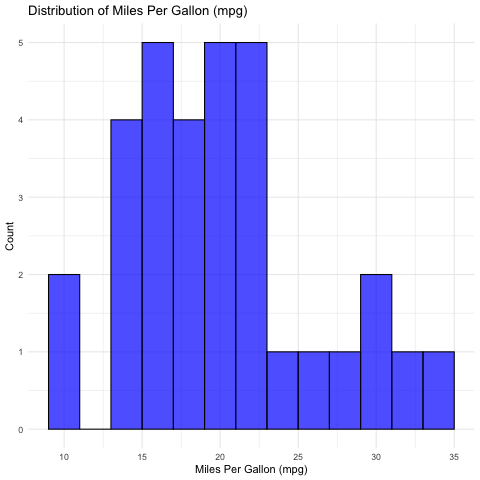

In [10]:
%%R 

# 👉 chart for mpg
mtcars %>%
  ggplot(aes(x = mpg)) +
  geom_histogram(binwidth = 2, fill = 'blue', color = 'black', alpha = 0.7) +
  labs(title = 'Distribution of Miles Per Gallon (mpg)', x = 'Miles Per Gallon (mpg)', y = 'Count') +
  theme_minimal()

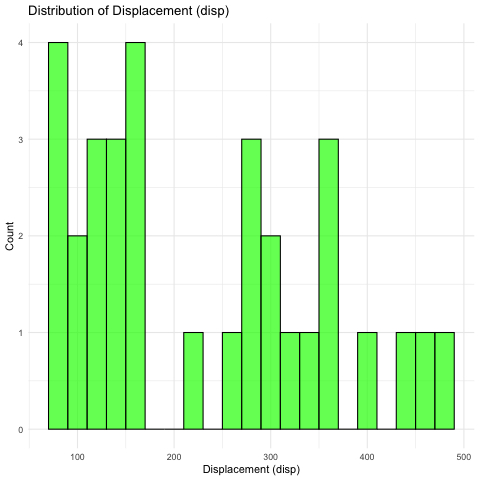

In [12]:
%%R 

# 👉 chart for disp

mtcars %>%
  ggplot(aes(x = disp)) +
  geom_histogram(binwidth = 20, fill = 'green', color = 'black', alpha = 0.7) +
  labs(title = 'Distribution of Displacement (disp)', x = 'Displacement (disp)', y = 'Count') +
  theme_minimal() 

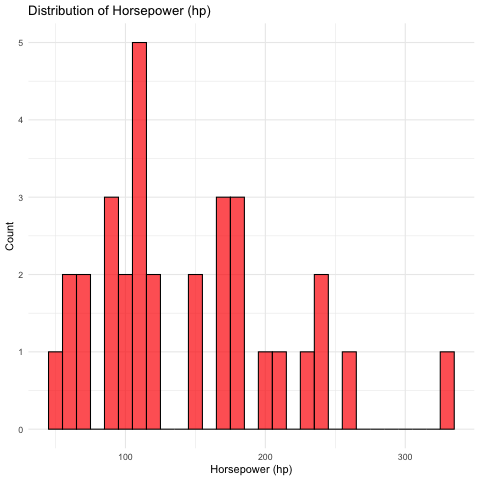

In [13]:
%%R 

# 👉 chart for hp

mtcars %>%
  ggplot(aes(x = hp)) +
  geom_histogram(binwidth = 10, fill = 'red', color = 'black    ', alpha = 0.7) +
  labs(title = 'Distribution of Horsepower (hp)', x = 'Horsepower (hp)', y = 'Count') +
  theme_minimal()

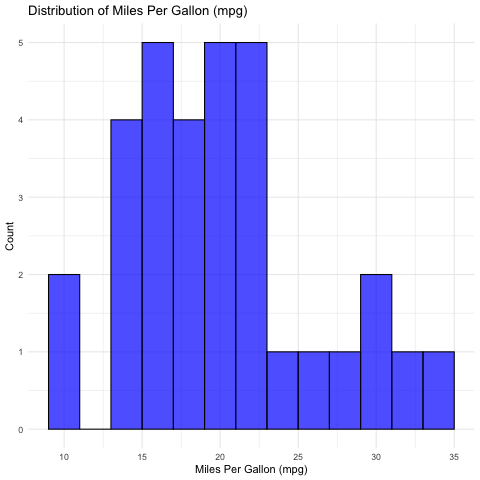

In [ ]:
%%R 

# 👉 chart for mpg

mtcars %>%
  ggplot(aes(x = mpg)) +
  geom_histogram(binwidth = 2, fill = 'blue', color = 'black', alpha = 0.7) +
  labs(title = 'Distribution of Miles Per Gallon (mpg)', x = 'Miles Per Gallon (mpg)', y = 'Count') +
  theme_minimal()

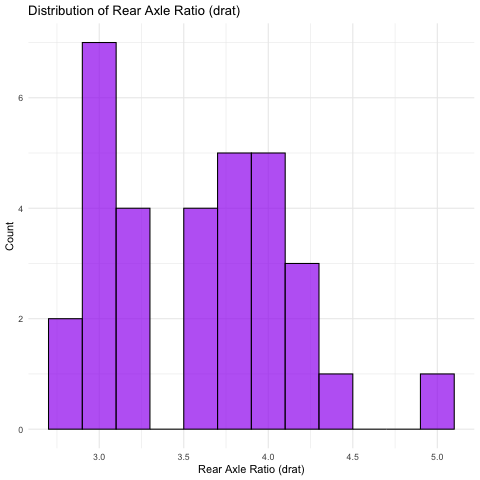

In [17]:
%%R 

# 👉 chart for drat

mtcars %>%
  ggplot(aes(x = drat)) +
  geom_histogram(binwidth = 0.2, fill = 'purple', color = 'black', alpha = 0.7) +
  labs(title = 'Distribution of Rear Axle Ratio (drat)', x = 'Rear Axle Ratio (drat)', y = 'Count') +
  theme_minimal()

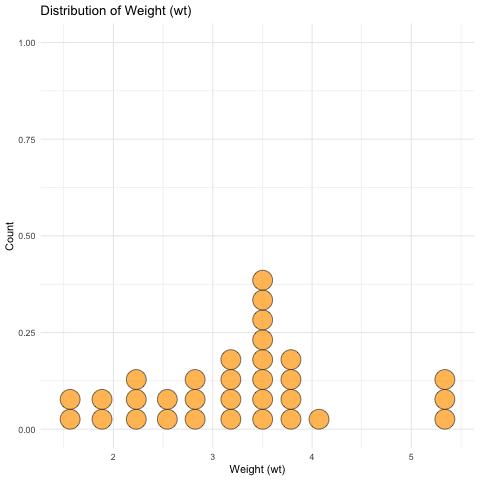

In [60]:
%%R 

# 👉 chart for wt

mtcars %>%
  ggplot(aes(x = wt)) + 
  geom_dotplot(binwidth = 0.2, fill = 'orange', color = 'black', alpha = 0.7) +
  labs(title = 'Distribution of Weight (wt)', x = 'Weight (wt)', y = 'Count') +
  theme_minimal()

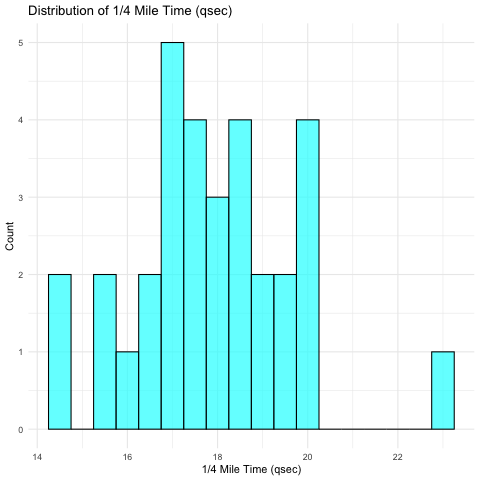

In [19]:
%%R 

# 👉 chart for qsec

mtcars %>%
  ggplot(aes(x = qsec)) + 
  geom_histogram(binwidth = 0.5, fill = 'cyan', color = 'black', alpha = 0.7) +
  labs(title = 'Distribution of 1/4 Mile Time (qsec)', x = '1/4 Mile Time (qsec)', y = 'Count') +
  theme_minimal()

Bonus: Write the ggplot code to reproduce the chart below


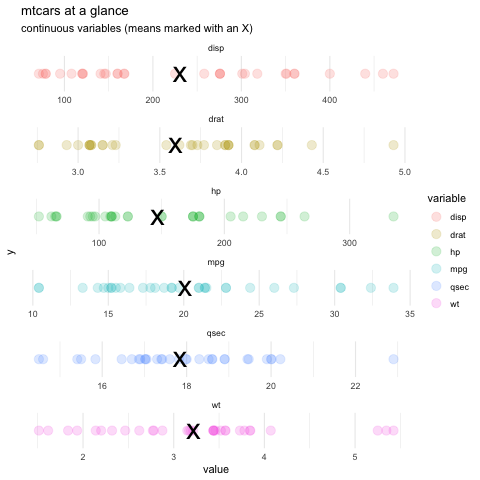

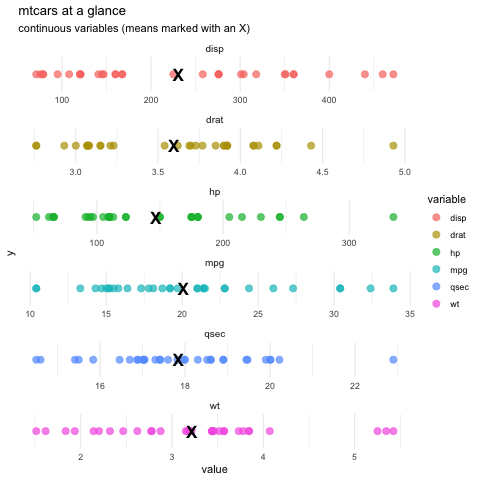

In [23]:
%%R

# Pivot data to long format for the continuous variables                                                                             
  mtcars_long <- mtcars |> 
    select(disp, drat, hp, mpg, qsec, wt) %>%                                                                                          
    pivot_longer(cols = everything(), names_to = "variable", values_to = "value") %>%                                                  
    mutate(variable = factor(variable, levels = c("disp", "drat", "hp", "mpg", "qsec", "wt")))                                         
                                                                                                                                       
  # Calculate means for each variable                                                                                                  
  means <- mtcars_long |>                                                                                                             
    group_by(variable) |>                                                                                                             
    summarize(mean_value = mean(value))                                                                                                
                                                                                                                                       
  # Define colors to match the image                                                                                                   
  colors <- c("disp" = "#F8766D", "drat" = "#B79F00", "hp" = "#00BA38",                                                                
              "mpg" = "#00BFC4", "qsec" = "#619CFF", "wt" = "#F564E3")                                                                 
                                                                                                                                       
  # Create the plot                                                                                                                    
  mtcars_long |>                                                                                                                      
    ggplot(aes(x = value, y = 0, color = variable)) +                                                                                  
    geom_point(alpha = 0.7, size = 3) +                                                                                                
    geom_text(data = means, aes(x = mean_value, y = 0),                                                                                
              label = "X", color = "black", size = 6, fontface = "bold") +                                                             
    facet_wrap(~ variable, scales = "free_x", ncol = 1) +                                                                              
    scale_color_manual(values = colors) +                                                                                              
    labs(title = "mtcars at a glance",                                                                                                 
         subtitle = "continuous variables (means marked with an X)",                                                                   
         x = "value",                                                                                                                  
         y = "y") +                                                                                                                    
    theme_minimal() +                                                                                                                  
    theme(                                                                                                                             
      strip.text = element_text(size = 10),                                                                                            
      axis.text.y = element_blank(),                                                                                                   
      axis.ticks.y = element_blank(),                                                                                                  
      panel.grid.major.y = element_blank(),                                                                                            
      panel.grid.minor.y = element_blank()                                                                                             
    )                                 

### Discrete Variables

Take the `mtcars` dataframe, `select` only the discrete variables, the use `pivot_longer` to pivot it from wide to long. Finally, use ggplot to make a column chart from the long dataframe that is faceted by the discrete variable. So you should end up with one chart, with subplots for each facet, like this:

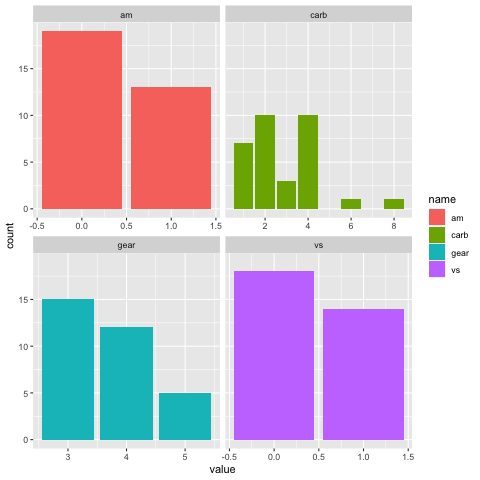

`summarise()` has grouped output by 'variable'. You can override using the
`.groups` argument.


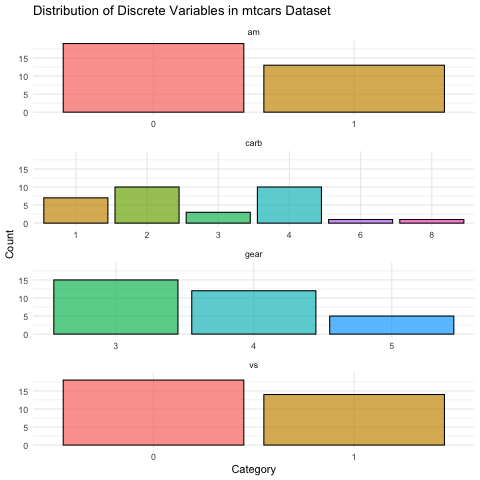

In [54]:
%%R 

discrete_variables <- c('vs', 'am', 'gear', 'carb')

# 👉 Write code to reproduce the chart above in this cell and give the chart a title
# 👉 Write four sentences below, one per subplot (these are just obesrvations)

mtcars |>
  select(all_of(discrete_variables)) |>
    pivot_longer(everything(), names_to = 'variable', values_to = 'value') |>
    group_by(variable, value) |>
    summarise(count = n()) |>
    ggplot(aes(x = factor(value), y = count, fill = factor(value))) +
    geom_bar(stat = 'identity', color = 'black', alpha = 0.7) +
    facet_wrap(~ variable, scales = 'free_x', ncol = 1) + 
    labs(title = 'Distribution of Discrete Variables in mtcars Dataset',
         x = 'Category',
         y = 'Count') +
    theme_minimal() +
    theme(legend.position = 'none') 

# Observations:
# 1. (0 indicates an automatic transmission and 1 indicates a manual transmission.) There are more automatic cars than manual ones.
# 2. (0 represents a V-shape engine and 1 represents a straight engine.) There are more V-shape engines than straight engines.
# 3. Most cars have either 3 or 4 gears, with fewer cars having 5 gears.
# 4. The number of carburetors varies, with 2 and 4 carburetors being the most common configurations.

👉 Run the cell below, observe the chart it creates. Then comment the code to demonstrate you understand what it does. Replace every `#add comment here` with a comment explaining what that part of the code does. If you're not sure, talk to ChatGPT about it.

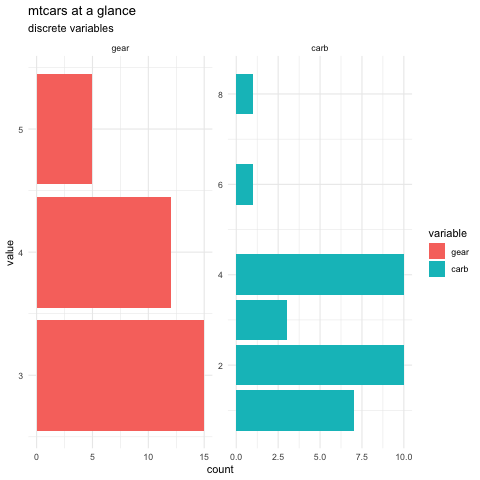

In [ ]:
%%R 

# Pivot data to long format for the discrete variables                                                                             
  mtcars_long_discrete <- mtcars |> 
    select(cyl, gear, carb) %>%                                                                                          
    pivot_longer(cols = everything(), names_to = "variable", values_to = "value") %>%                                                  
    mutate(variable = factor(variable, levels = c("cyl", "gear", "carb")))

# plot only discrete variables
to_plot <- mtcars_long_discrete %>% filter(variable %in% discrete_variables)
to_plot
plot_discrete <- ggplot(to_plot) +
    aes(y=value, fill=variable) +
    geom_bar() +
    facet_wrap(~variable, scales='free') +
    theme_minimal() +
    labs(title = 'mtcars at a glance', subtitle='discrete variables')

plot_discrete

# It shows how many cars fall into each category for two features in the mtcars dataset:
  # Gear panel: the count of cars with 3, 4, or 5 gears. Most cars have 3 gears, fewer have 4, and very few have 5.
  # Carb panel: the count of cars by number of carburetors (1, 2, 3, 4, 6, 8). The most common are 2 and 4 carburetors, while the higher numbers are rare.
# In short: it’s a pair of bar charts showing the frequency distribution of gears and carburetors across the cars.

## Visual Choices Questions

👉 What is a discrete variable vs a continuous variable?

👉 Why did I chose a bar chart for the discrete variables and distributions for the continuous variables?

In [ ]:
# Discrete variables provide categorical information about the cars, such as the number of gears and carburetors. They cannot have an in-between value, unlike continuous variables which can take any value within a range.

# Bar charts effectively display the frequency or count of each category, making it easy to compare the number of occurrences across different groups.
# Dot plots are preferred for continuous variables as they show the distribution of data points along a continuous scale, allowing for better visualization of density and clustering.

👉 What can you tell me about these cars after looking at the charts above?

In [ ]:
# drat and qsec sit in relatively narrow bands. Cars are fairly similar on these measures.
# disp, hp, and mpg stretch widely. Large mechanical differences between cars.

# The mean fuel economy is being lifted by a handful of very efficient cars. In the mpg plot, most cars cluster around lower mpg values, but a few cars have very high mpg, which raises the average. This indicates that while the average mpg is relatively high, it does not represent the typical car in the dataset, as most cars have lower mpg values.

# For weight, one groups around ~2000–3500 lbs, while another near ~4000–5500 lbs. We should check what variable splits these group: Cylinders? Horsepower? Transmission?

# Acceleration (qsec) is surprisingly uniform. Compared to engine size and horsepower, acceleration times don't vary dramatically. That could suggest engineering constraints. Even very different cars still land within a similar performance window. 

# Horsepower (hp) and displacement (disp) show strong right tails. Most cars are moderate, but a few are much more powerful/ has a larger-engine than the rest.

👉 What further questions about this data do you have now? 

In [ ]:
# Is the “average car” a misleading concept here? When distributions are wide or clustered, the mean can describe a car that doesn’t really exist.
# What is the main axis that organizes this dataset? Could it be vehicle size or performance intensity?
# We could also try to investigate what explains fuel efficiency, as this appears to be the most economically meaningful variable in the table. Does weight kill mpg? Does horsepower? Is transmission involved? Do more gears help?

### OTHER THINGS WE LEARNT IN CLASS. IGNORE FROM HERE. 

In [61]:
%%R

mtcars_longer = mtcars |>
    pivot_longer(cols = c(-name, -mpg),
    names_to = 'measurement',
    values_to = 'value')

mtcars_longer    

# A tibble: 320 × 4
   name        mpg measurement  value
   <chr>     <dbl> <chr>        <dbl>
 1 Mazda RX4    21 cyl           6   
 2 Mazda RX4    21 disp        160   
 3 Mazda RX4    21 hp          110   
 4 Mazda RX4    21 drat          3.9 
 5 Mazda RX4    21 wt            2.62
 6 Mazda RX4    21 qsec         16.5 
 7 Mazda RX4    21 vs            0   
 8 Mazda RX4    21 am            1   
 9 Mazda RX4    21 gear          4   
10 Mazda RX4    21 carb          4   
# ℹ 310 more rows
# ℹ Use `print(n = ...)` to see more rows


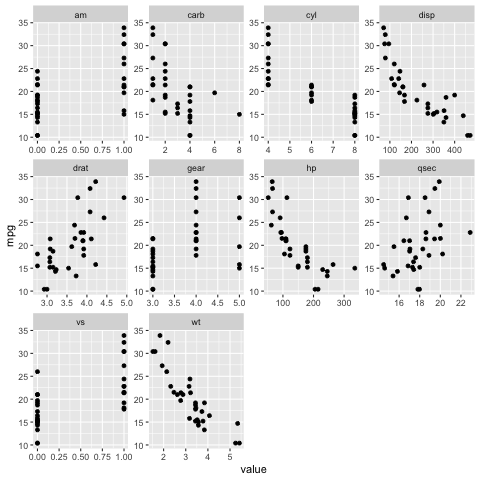

In [32]:
%%R

ggplot(mtcars_longer) +
    aes(x = value, y=mpg) +
    geom_point() +
    facet_wrap(~measurement, scales='free')

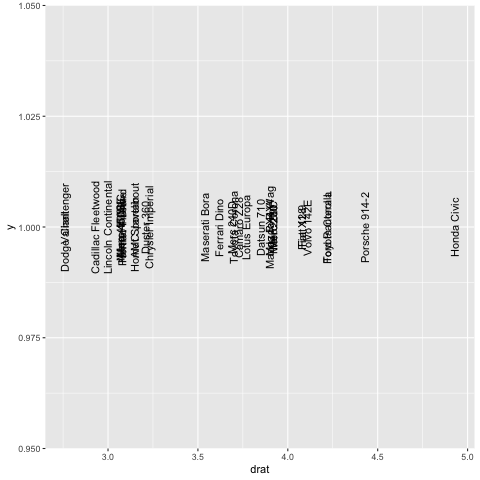

In [75]:
%%R 

ggplot(mtcars) + 
    aes(x=drat, y=1, label=name) +
    geom_text(angle=90)